In [ ]:
!pip install -q rfdetr>=1.4.0 supervision roboflow

In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="kAnFM4vuNJWm5DKRv8co")
project = rf.workspace("hacker-gs2qc").project("pothole-segmentation-g6hbh-4y7lj")
version = project.version(2)
dataset = version.download("coco-segmentation")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
import json

with open("/content/Pothole-Segmentation-2/train/_annotations.coco.json") as f:
    data = json.load(f)

print(f"Classes: {[cat['name'] for cat in data['categories']]}")
print(f"Train images: {len(data['images'])}")
print(f"Train annotations: {len(data['annotations'])}")

Classes: ['Pothole-Segmentation', 'Manhole', 'Pothole', 'Potholes', 'Unmarked Bump', 'pothole']
Train images: 1242
Train annotations: 2648


In [ ]:
from rfdetr import RFDETRSegNano

model = RFDETRSegNano()

model.train(dataset_dir="/content/Pothole-Segmentation-2", epochs=5, batch_size=4, grad_accum_steps=4)

[2026-04-30 01:42:44] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-04-30 01:42:44] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-30 01:42:44] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-30 01:42:45] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


[2026-04-30 01:42:45] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-30 01:42:45] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.


[2026-04-30 01:42:46] [INFO] rf-detr - File rf-detr-seg-nano.pt already exists with correct MD5 hash.


...

[2026-04-30 01:42:46] [INFO] rf-detr - Building Roboflow train dataset with square resize at resolution 312
[2026-04-30 01:42:46] [INFO] rf-detr - Using multi-scale training with square resize and scales: [372]
[2026-04-30 01:42:46] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-30 01:42:46] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
[2026-04-30 01:42:46] [INFO] rf-detr - Building Roboflow val dataset with square resize at resolution 312
[2026-04-30 01:42:46] [INFO] rf-detr - Using multi-scale training with square resize and scales: [372]
[2026-04-30 01:42:46] [INFO] rf-detr - Built 1 Albumentations transforms from config
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Checkpoint directory /content/output exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.utilities.rank_zero:Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name        ┃ Type         ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model       │ LWDETR       │ 33.3 M │ train │     0 │
│ 1 │ criterion   │ SetCriterion │      0 │ train │     0 │
│ 2 │ postprocess │ PostProcess  │      0 │ train │     0 │
└───┴─────────────┴──────────────┴────────┴───────┴───────┘

Trainable params: 33.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 33.3 M                                                                                               
Total estimated model params size (MB): 133                                                                        
Modules in train mode: 513                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [ ]:
model = RFDETRSegNano(pretrain_weights="/content/output/checkpoint_best_total.pth")
model.optimize_for_inference()

[2026-04-30 02:24:22] [WARNING] rf-detr - Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-30 02:24:22] [WARNING] rf-detr - Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
[2026-04-30 02:24:22] [WARNING] rf-detr - Checkpoint has 6 classes but model is configured for 90. Using checkpoint class count (6). Pass num_classes=6 to suppress this warning.


In [ ]:
import supervision as sv

ds_test = sv.DetectionDataset.from_coco(
    images_directory_path="/content/Pothole-Segmentation-2/test",
    annotations_path="/content/Pothole-Segmentation-2/test/_annotations.coco.json",
    force_masks=True
)

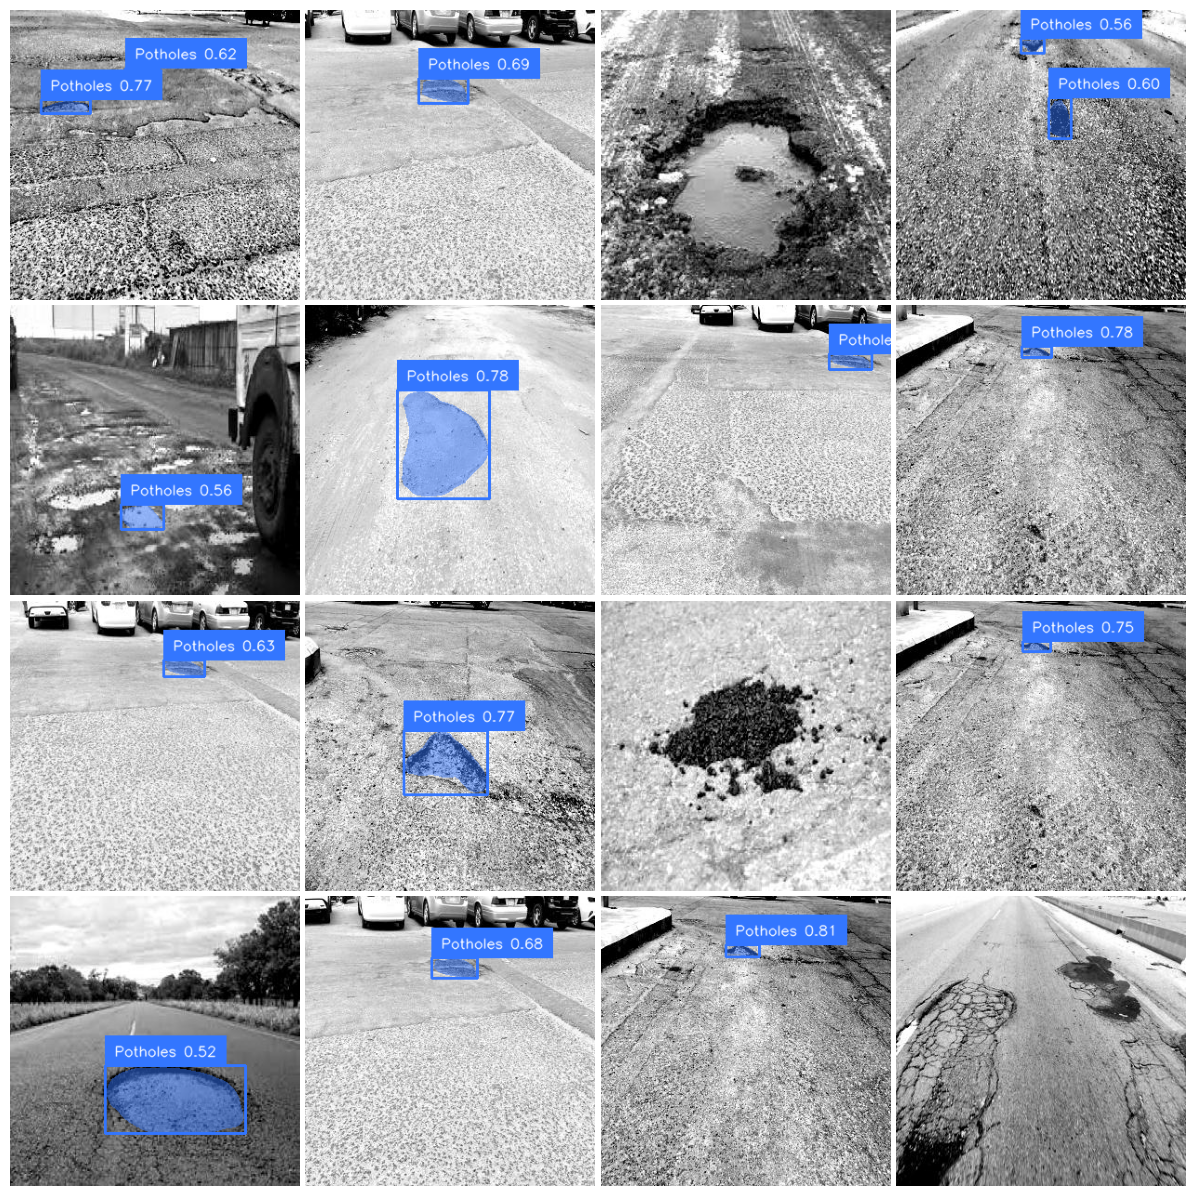

In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import supervision as sv

# Define annotators
box_annotator = sv.BoxAnnotator()
label_annotator = sv.LabelAnnotator()
mask_annotator = sv.MaskAnnotator()

N = 16
L = len(ds_test)

classes = ds_test.classes

annotated_images = []

for i in random.sample(range(L), N):
    path, _, annotations = ds_test[i]
    image = Image.open(path)

    # ✅ Fixed: .infer() → .predict()
    # predict() returns sv.Detections directly, no need for from_inference()
    detections = model.predict(image, threshold=0.5)

    # Convert PIL to numpy for supervision
    image_np = np.array(image)

    # Build labels
    labels = [
        f"{classes[class_id]} {conf:.2f}"
        for class_id, conf in zip(detections.class_id, detections.confidence)
    ]

    annotated_image = image_np.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)
    annotated_image = label_annotator.annotate(annotated_image, detections, labels=labels)

    annotated_images.append(annotated_image)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))

for ax, img in zip(axes.flat, annotated_images):
    ax.imshow(img)
    ax.axis("off")

plt.subplots_adjust(wspace=0.02, hspace=0.02, left=0.01, right=0.99, top=0.99, bottom=0.01)
plt.show()